In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential,load_model,Model
from tensorflow.keras.preprocessing import image

from tensorflow.keras.applications import DenseNet121,ResNet50,VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten

# PreProcessing

In [ ]:
IMG_SIZE = (224, 224)
# Load image files
train_dir = r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\Covid19Detection\Data\Covid19-dataset\train"
test_dir = r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\Covid19Detection\Data\Covid19-dataset\test"

train_dataset = image_dataset_from_directory(
                                                train_dir,
                                                validation_split=0.2,   # 20% for validation
                                                subset="training",
                                                seed=42,
                                                image_size=IMG_SIZE,
                                                batch_size=32
                                            )

val_dataset = image_dataset_from_directory(
                                                train_dir,
                                                validation_split=0.2,
                                                subset="validation",
                                                seed=42,
                                                image_size=IMG_SIZE,
                                                batch_size=32
                                            )

test_dataset = image_dataset_from_directory(
                                                test_dir,
                                                image_size=IMG_SIZE,
                                                batch_size=32
                                            )

class_names=train_dataset.class_names
n_classes=len(class_names)
print(class_names)
print(n_classes)

# Rescaling
def image_resize_and_rescale(img):
  img=img/255.0
  img=tf.image.resize(img,[224,224])
  return img

train_dataset=train_dataset.map(lambda x,y: (image_resize_and_rescale(x),y))
val_dataset=val_dataset.map(lambda x,y: (image_resize_and_rescale(x),y))
test_dataset=test_dataset.map(lambda x,y: (image_resize_and_rescale(x),y))

# Data Augmentation
data_augmentation = tf.keras.Sequential([
                                            tf.keras.layers.RandomRotation(0.05),
                                            tf.keras.layers.RandomZoom(0.10),
                                            tf.keras.layers.RandomTranslation(0.05, 0.05),
                                            tf.keras.layers.RandomContrast(0.10)
                                        ])

augmented_ds = train_dataset.map(lambda x, y: (data_augmentation(x, training=True), y))
train_dataset=train_dataset.concatenate(augmented_ds)

# Optimize dataset
autotune=tf.data.AUTOTUNE
train_dataset=train_dataset.cache().prefetch(buffer_size=autotune)
val_dataset=val_dataset.cache().prefetch(buffer_size=autotune)
test_dataset=test_dataset.cache().prefetch(buffer_size=autotune)

Found 251 files belonging to 3 classes.
Using 201 files for training.


Found 251 files belonging to 3 classes.
Using 50 files for validation.
Found 66 files belonging to 3 classes.
['Covid', 'Normal', 'Viral Pneumonia']
3


In [3]:
# Extract labels from training dataset
labels = np.concatenate([
    y.numpy() for _, y in train_dataset
])

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.7528089887640449), 1: np.float64(1.1355932203389831), 2: np.float64(1.2641509433962264)}


# ResNet50

In [4]:
base_model = ResNet50(weights='imagenet',include_top=False,input_shape=(224,224,3))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(3, activation='softmax')(x)

resNet_model = Model(base_model.input, output)

# Compile
resNet_model.compile(
                        optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy']
                    )

# Training
history = resNet_model.fit(
                                train_dataset,
                                validation_data=val_dataset,
                                epochs=10,
                                class_weight=class_weights
                            )

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.3781 - loss: 1.3173 - val_accuracy: 0.4600 - val_loss: 0.9966
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.4552 - loss: 1.0701 - val_accuracy: 0.5200 - val_loss: 0.9361
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.5423 - loss: 0.9639 - val_accuracy: 0.5600 - val_loss: 0.8873
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.5995 - loss: 0.9052 - val_accuracy: 0.6400 - val_loss: 0.8520
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.6443 - loss: 0.8634 - val_accuracy: 0.7000 - val_loss: 0.8170
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.6716 - loss: 0.8043 - val_accuracy: 0.6600 - val_loss: 0.7917
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.6393 - loss: 0.8271 - val_accuracy: 0.6600 - val_loss: 0.7759
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.6741 - loss: 0.7850 - val_accuracy: 0.6800 - val_loss:

In [5]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = resNet_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89        26
           1       0.64      0.90      0.75        20
           2       0.70      0.35      0.47        20

    accuracy                           0.74        66
   macro avg       0.73      0.72      0.70        66
weighted avg       0.74      0.74      0.72        66



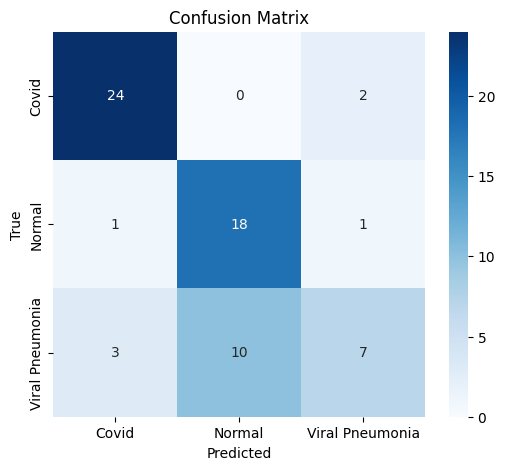

In [6]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [7]:
loss, acc = resNet_model.evaluate(test_dataset)
print("Loaded Model Accuracy:", acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.7424 - loss: 0.5829
Loaded Model Accuracy: 0.7424242496490479


# Fine-Tuning ResNet50

In [8]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [9]:
print("Trainable Layers:")

for layer in base_model.layers[-10:]:
    print(layer.name, layer.trainable)

Trainable Layers:
conv5_block3_1_conv True
conv5_block3_1_bn True
conv5_block3_1_relu True
conv5_block3_2_conv True
conv5_block3_2_bn True
conv5_block3_2_relu True
conv5_block3_3_conv True
conv5_block3_3_bn True
conv5_block3_add True
conv5_block3_out True


In [10]:
resNet_model.compile(
                optimizer=tf.keras.optimizers.Adam(1e-5),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
            )

history_fine = resNet_model.fit(
                                    train_dataset,
                                    validation_data=val_dataset,
                                    epochs=10
                                )

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 73s 4s/step - accuracy: 0.4677 - loss: 2.9160 - val_accuracy: 0.6600 - val_loss: 0.8929
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 53s 4s/step - accuracy: 0.7562 - loss: 0.6353 - val_accuracy: 0.4400 - val_loss: 1.1498
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 53s 4s/step - accuracy: 0.8408 - loss: 0.4041 - val_accuracy: 0.2600 - val_loss: 1.5286
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 55s 4s/step - accuracy: 0.8657 - loss: 0.3310 - val_accuracy: 0.2200 - val_loss: 2.1085
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 54s 4s/step - accuracy: 0.9154 - loss: 0.2493 - val_accuracy: 0.2200 - val_loss: 2.6319
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 53s 4s/step - accuracy: 0.9403 - loss: 0.1961 - val_accuracy: 0.2200 - val_loss: 3.0774
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 53s 4s/step - accuracy: 0.9776 - loss: 0.1448 - val_accuracy: 0.2200 - val_loss: 3.3264
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step - accuracy: 0.9851 - loss: 0.1077 - val_accuracy: 0.2200 - val_loss:

In [11]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = resNet_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        26
           1       0.30      1.00      0.47        20
           2       0.00      0.00      0.00        20

    accuracy                           0.30        66
   macro avg       0.10      0.33      0.16        66
weighted avg       0.09      0.30      0.14        66



c:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

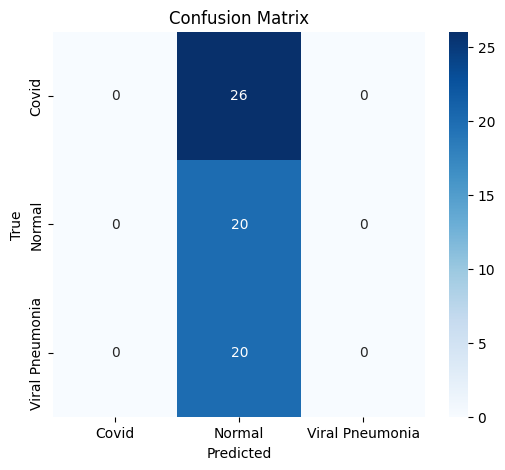

In [21]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# DenseNet

In [ ]:
base_model = DenseNet121(weights='imagenet',include_top=False,input_shape=(224,224,3))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(3, activation='softmax')(x)

densenet_model = Model(inputs=base_model.input,outputs=output)

# Compile
densenet_model.compile(
                optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
            )

# Training
history = densenet_model.fit(
                        train_dataset,
                        validation_data=val_dataset,
                        epochs=10,
                        class_weight=class_weights
                    )

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 0.6119 - loss: 0.9969 - val_accuracy: 0.8400 - val_loss: 0.5071
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.8109 - loss: 0.5008 - val_accuracy: 0.8200 - val_loss: 0.4602
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.8706 - loss: 0.3369 - val_accuracy: 0.7800 - val_loss: 0.6189
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.8706 - loss: 0.3749 - val_accuracy: 0.7800 - val_loss: 0.6610
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 110s 8s/step - accuracy: 0.8881 - loss: 0.3001 - val_accuracy: 0.9000 - val_loss: 0.3709
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.9204 - loss: 0.2295 - val_accuracy: 0.9000 - val_loss: 0.3469
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.9378 - loss: 0.1782 - val_accuracy: 0.8400 - val_loss: 0.4467
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9527 - loss: 0.1858 - val_accuracy: 0.9000 - val_loss

In [8]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = densenet_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        26
           1       0.65      1.00      0.78        20
           2       1.00      0.55      0.71        20

    accuracy                           0.83        66
   macro avg       0.88      0.82      0.82        66
weighted avg       0.89      0.83      0.83        66



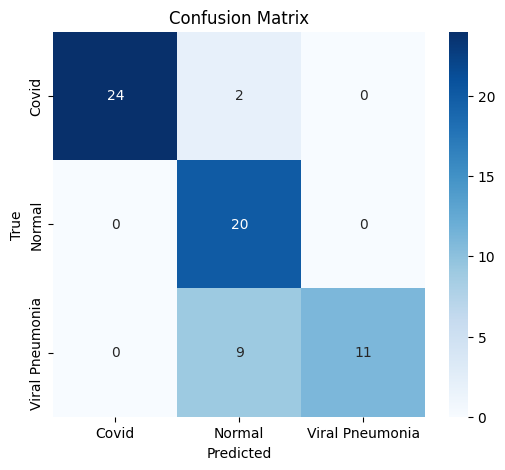

In [13]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [14]:
densenet_model.save(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\Covid19Detection\Model\denseNet_covid_model.keras")
saved_model = load_model(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\Covid19Detection\Model\denseNet_covid_model.keras")
loss, acc = saved_model.evaluate(test_dataset)
print("Loaded Model Accuracy:", acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8333 - loss: 0.4231
Loaded Model Accuracy: 0.8333333134651184


# VGG16

In [15]:
base_model = VGG16(weights='imagenet',include_top=False,input_shape=(224,224,3))
base_model.trainable = False

x = Flatten()(base_model.output)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(3, activation='softmax')(x)

vgg16_model = Model(base_model.input, output)

# Compile
vgg16_model.compile(
                        optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy']
                    )

# Training
history = vgg16_model.fit(
                        train_dataset,
                        validation_data=val_dataset,
                        epochs=10,
                        class_weight=class_weights
                    )

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 66s 4s/step - accuracy: 0.5149 - loss: 2.8115 - val_accuracy: 0.8000 - val_loss: 0.6942
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 70s 5s/step - accuracy: 0.8682 - loss: 0.4040 - val_accuracy: 0.8600 - val_loss: 0.7294
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 85s 6s/step - accuracy: 0.9303 - loss: 0.2567 - val_accuracy: 0.8200 - val_loss: 0.5658
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 86s 6s/step - accuracy: 0.9229 - loss: 0.2232 - val_accuracy: 0.8800 - val_loss: 0.4444
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 83s 6s/step - accuracy: 0.9378 - loss: 0.2246 - val_accuracy: 0.9200 - val_loss: 0.2278
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 79s 6s/step - accuracy: 0.9602 - loss: 0.1325 - val_accuracy: 0.9000 - val_loss: 0.1527
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 88s 6s/step - accuracy: 0.9751 - loss: 0.0926 - val_accuracy: 0.9400 - val_loss: 0.1403
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 104s 7s/step - accuracy: 0.9826 - loss: 0.0819 - val_accuracy: 0.9200 - val_loss

In [16]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = vgg16_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      0.90      0.95        20
           2       0.91      1.00      0.95        20

    accuracy                           0.97        66
   macro avg       0.97      0.97      0.97        66
weighted avg       0.97      0.97      0.97        66



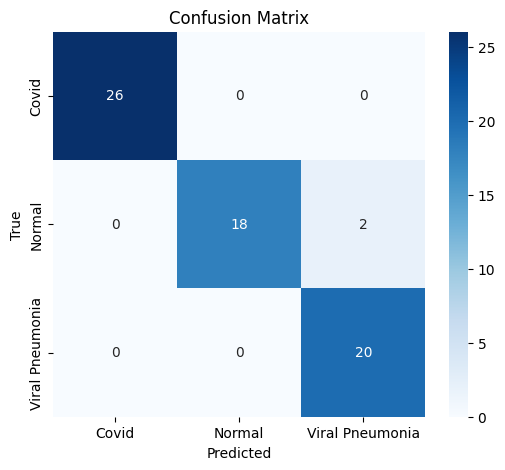

In [17]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [18]:
vgg16_model.save(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\Covid19Detection\Model\vgg16_covid_model.keras")
saved_model = load_model(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\Covid19Detection\Model\vgg16_covid_model.keras")
loss, acc = saved_model.evaluate(test_dataset)
print("Loaded Model Accuracy:", acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.9697 - loss: 0.1016
Loaded Model Accuracy: 0.9696969985961914
